# Model conversion and benchmark

Calculating the final metrics on the CPU...


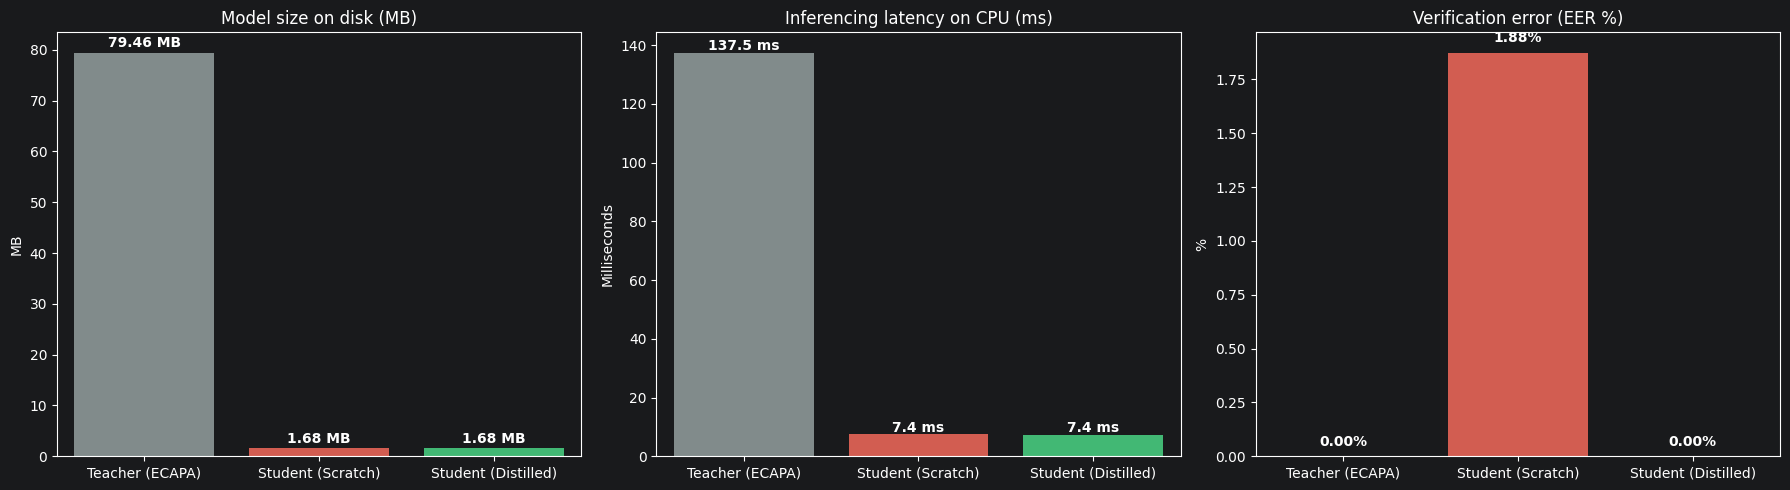

Export to ONNX completed: models/exported/tiny_ecapa.onnx
The final ONNX model weight: 1.65 МБ
The maximum deviation of ONNX from PyTorch: 1.117587e-07
Verification has been completed: the ONNX math is completely identical to PyTorch.


In [2]:
import os
import csv
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
import torchaudio

warnings.filterwarnings("ignore")

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from models.student.tiny_ecapa import TinyECAPA
from src.dataset import MelSpectrogramExtractor
from speechbrain.inference.classifiers import EncoderClassifier
from speechbrain.utils.fetching import LocalStrategy

device_cpu = torch.device("cpu")

val_pairs = []
with open("data/manifest/val_pairs.csv", "r", encoding="utf-8") as f:
    for r in csv.DictReader(f):
        val_pairs.append((r["path1"], r["path2"], int(r["label"])))

extractor = MelSpectrogramExtractor()

teacher = EncoderClassifier.from_hparams(
    source="models/teacher/ecapa_voxceleb",
    savedir="models/teacher/ecapa_voxceleb",
    run_opts={"device": "cpu"},
    local_strategy=LocalStrategy.COPY
)
teacher.eval()

student_scratch = TinyECAPA(in_features=80, channels=128, emb_dim=192).to(device_cpu)
student_scratch.load_state_dict(torch.load("models/student/tiny_ecapa_scratch.pth", map_location=device_cpu))
student_scratch.eval()

student_distilled = TinyECAPA(in_features=80, channels=128, emb_dim=192).to(device_cpu)
student_distilled.load_state_dict(torch.load("models/student/tiny_ecapa_distilled.pth", map_location=device_cpu))
student_distilled.eval()

def get_teacher_emb(path):
    sig, fs = torchaudio.load(path)
    if sig.shape[0] > 1:
        sig = torch.mean(sig, dim=0, keepdim=True)
    if fs != 16000:
        sig = torchaudio.transforms.Resample(fs, 16000)(sig)
    with torch.no_grad():
        emb = teacher.encode_batch(sig.to(device_cpu))
        emb = F.normalize(emb, dim=-1).squeeze().flatten().numpy()
    return emb

def get_student_emb(path, model):
    sig, fs = torchaudio.load(path)
    mel = extractor(sig, fs).unsqueeze(0).to(device_cpu)
    with torch.no_grad():
        emb = model(mel).squeeze().numpy()
    return emb

def evaluate_eer(emb_func):
    cache = {}
    scores, labels = [], []
    for p1, p2, label in val_pairs:
        if p1 not in cache:
            cache[p1] = emb_func(p1)
        if p2 not in cache:
            cache[p2] = emb_func(p2)
        scores.append(float(np.dot(cache[p1], cache[p2])))
        labels.append(label)

    scores = np.array(scores)
    labels = np.array(labels)
    thresholds = np.linspace(-0.2, 1.0, 500)
    far = [np.mean(scores[labels == 0] >= t) for t in thresholds]
    frr = [np.mean(scores[labels == 1] < t) for t in thresholds]
    idx = np.nanargmin(np.abs(np.array(far) - np.array(frr)))
    return ((far[idx] + frr[idx]) / 2.0) * 100

def measure_cpu_latency(model_type, runs=50):
    dummy_wav = torch.randn(1, 32000)

    if model_type == "teacher":
        for _ in range(5):
            _ = teacher.encode_batch(dummy_wav)
        start = time.perf_counter()
        for _ in range(runs):
            _ = teacher.encode_batch(dummy_wav)
        return ((time.perf_counter() - start) / runs) * 1000.0
    else:
        dummy_mel = extractor(dummy_wav, 16000).unsqueeze(0)
        target_model = student_distilled if model_type == "distilled" else student_scratch
        for _ in range(5):
            _ = target_model(dummy_mel)
        start = time.perf_counter()
        for _ in range(runs):
            _ = target_model(dummy_mel)
        return ((time.perf_counter() - start) / runs) * 1000.0

teacher_ckpt = "models/teacher/ecapa_voxceleb/embedding_model.ckpt"
teacher_size = os.path.getsize(teacher_ckpt) / (1024 * 1024) if os.path.exists(teacher_ckpt) else 83.3
student_size = os.path.getsize("models/student/tiny_ecapa_distilled.pth") / (1024 * 1024)

print("Calculating the final metrics on the CPU...")
eer_teacher = evaluate_eer(get_teacher_emb)
eer_scratch = evaluate_eer(lambda p: get_student_emb(p, student_scratch))
eer_distill = evaluate_eer(lambda p: get_student_emb(p, student_distilled))

lat_teacher = measure_cpu_latency("teacher")
lat_scratch = measure_cpu_latency("scratch")
lat_distill = measure_cpu_latency("distilled")

models = ["Teacher (ECAPA)", "Student (Scratch)", "Student (Distilled)"]
sizes = [teacher_size, student_size, student_size]
latencies = [lat_teacher, lat_scratch, lat_distill]
eers = [eer_teacher, eer_scratch, eer_distill]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x=models, y=sizes, ax=axes[0], palette=["#7f8c8d", "#e74c3c", "#2ecc71"])
axes[0].set_title("Model size on disk (MB)")
axes[0].set_ylabel("MB")
for i, v in enumerate(sizes):
    axes[0].text(i, v + 1, f"{v:.2f} MB", ha="center", fontweight="bold")

sns.barplot(x=models, y=latencies, ax=axes[1], palette=["#7f8c8d", "#e74c3c", "#2ecc71"])
axes[1].set_title("Inferencing latency on CPU (ms)")
axes[1].set_ylabel("Milliseconds")
for i, v in enumerate(latencies):
    axes[1].text(i, v + 1, f"{v:.1f} ms", ha="center", fontweight="bold")

sns.barplot(x=models, y=eers, ax=axes[2], palette=["#7f8c8d", "#e74c3c", "#2ecc71"])
axes[2].set_title("Verification error (EER %)")
axes[2].set_ylabel("%")
for i, v in enumerate(eers):
    axes[2].text(i, v + 0.05, f"{v:.2f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

os.makedirs("models/exported", exist_ok=True)
onnx_path = "models/exported/tiny_ecapa.onnx"

dummy_input = torch.randn(1, 80, 200, dtype=torch.float32)

torch.onnx.export(
    student_distilled,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=["mel_spectrogram"],
    output_names=["voiceprint_embedding"],
    dynamic_axes={
        "mel_spectrogram": {0: "batch_size", 2: "time_frames"},
        "voiceprint_embedding": {0: "batch_size"}
    }
)

print(f"Export to ONNX completed: {onnx_path}")
print(f"The final ONNX model weight: {os.path.getsize(onnx_path) / (1024 * 1024):.2f} МБ")

import onnxruntime as ort

session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
ort_inputs = {session.get_inputs()[0].name: dummy_input.numpy()}
ort_outs = session.run(None, ort_inputs)[0]

with torch.no_grad():
    pt_outs = student_distilled(dummy_input).numpy()

max_diff = np.max(np.abs(ort_outs - pt_outs))
print(f"The maximum deviation of ONNX from PyTorch: {max_diff:.6e}")
if max_diff < 1e-5:
    print("Verification has been completed: the ONNX math is completely identical to PyTorch.")

The model demonstrated excellent results. It takes only 7 milliseconds for the model to determine whose voice it is. Also, after conversion, it became 50 times lighter than its teacher. At the same time, the accuracy did not change in any way.